In [1]:
import numpy as np

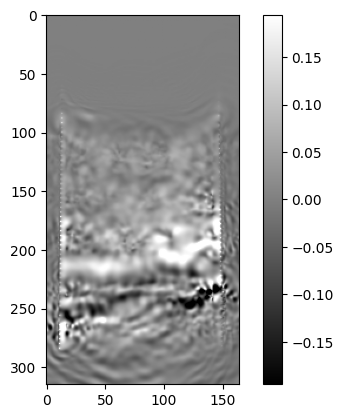

In [10]:
from matplotlib import pyplot as plt
# buff = np.diff(grad0.T[:-50, 50:-50], axis=0)
grad0 = np.load("gradients/grad_full_29.npy")
buff = grad0.T[:-50, 50:-50]

qa = np.quantile(buff, 0.99)
h=plt.imshow(buff, cmap='gray', vmin=-qa, vmax=qa)
plt.gcf().colorbar(h)
plt.show()

In [11]:
from config import *
import torch
def get_model_shape():
    return 2630, 3640

def get_num_shots():
    return 59
def load_wavefield_snaps_batch(shot_ids, wavefield_type='forward'):
    dir_path = OUTPUT_DIRS['forward_snaps'] if wavefield_type == 'forward' else OUTPUT_DIRS['adjoint_snaps']
    nx, nz = get_model_shape()
    sub_nx = nx // SUBSAMPLING + 1
    sub_nz = nz // SUBSAMPLING + 1
    
    batch = torch.empty((len(shot_ids), NSNAPS, sub_nx, sub_nz),
                    dtype=torch.float32,
                    pin_memory=True)
    
    for i, shot_id in enumerate(shot_ids):
        path = f"{dir_path}/{shot_id+1}.npy"
        batch[i] = torch.from_numpy(np.load(path))  # Copy forces read into memory
    
    return batch

In [14]:
shot_ids = range(0, get_num_shots(), 10)
# shot_ids = range(0, 20, 10)

u0_batch = load_wavefield_snaps_batch(shot_ids, 'forward')
v_batch = load_wavefield_snaps_batch(shot_ids, 'adjoint')

print(u0_batch.numpy().shape)

(6, 500, 264, 365)


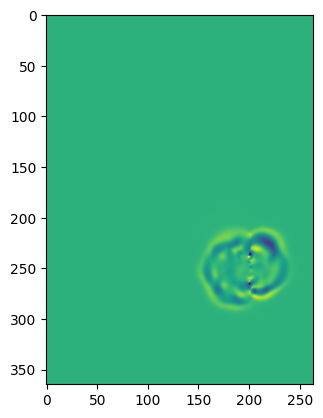

In [27]:
plt.imshow(u0_batch.numpy()[5][70].T)
plt.show()

In [28]:
grad = np.load("images/image_iter_1.npy")

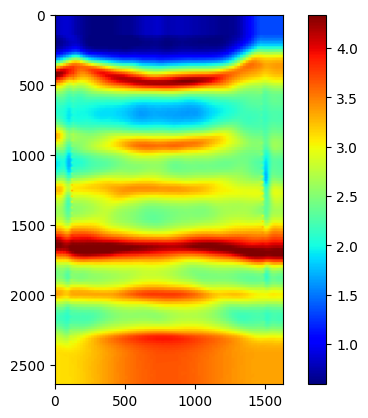

In [29]:
from matplotlib import pyplot as plt
from scipy.ndimage import laplace
# buff = np.diff(grad.T[:-500, 500:-500], axis=0)
# buff = laplace(grad.T[:-500, 500:-500])

buff = grad.T[500:-500, 500:-500]
qa1 = np.quantile(buff, 0.01)
qa2 = np.quantile(buff, 0.99)
h = plt.imshow(buff, cmap='jet', vmin=qa1, vmax=qa2)
plt.gcf().colorbar(h)
plt.show()

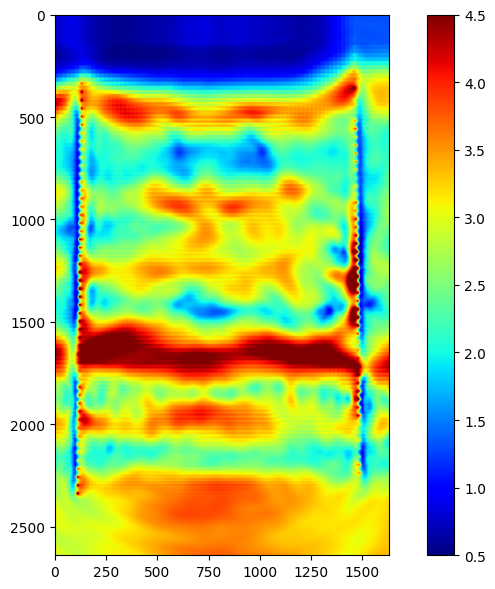

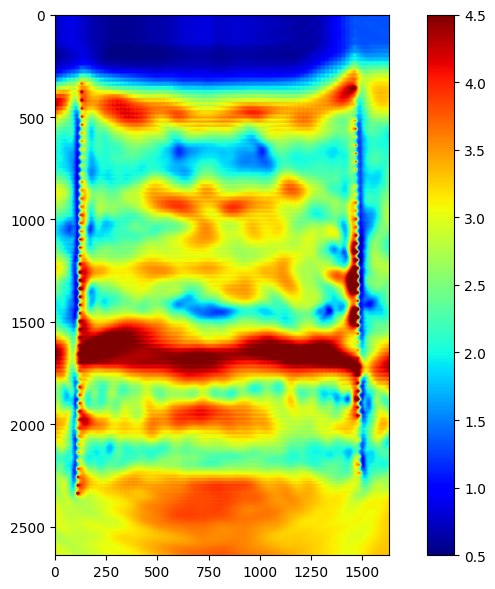

In [26]:
for i in range(17, 19):
    path = f"images/image_iter_{i}.npy"
    grad1 = np.load(path)
    path = f"images/image_iter_{0}.npy"
    grad0 = np.load(path)
    buff = (grad1-grad0).T[500:-500, 500:-500]
    qa1 = np.quantile(buff, 0.1)
    qa2 = np.quantile(buff, 0.9)
    buff = grad1.T[500:-500, 500:-500]
    # h = plt.imshow(buff, cmap='jet', vmin=qa1, vmax=qa2)
    h = plt.imshow(buff, cmap='jet', vmin=0.5, vmax=4.5)
    plt.gcf().colorbar(h)
    plt.tight_layout()
    plt.savefig(f"_{i}.png")
    plt.show()

In [4]:
from wavefield_computation import setup_model_and_geometry
import numpy as np
model, dataset = setup_model_and_geometry(29)

(1630, 2640)


Operator `initdamp` ran in 0.01 s


In [5]:
from config import *
d_syn = np.load(f"{OUTPUT_DIRS['forward_snaps']}/recon_gather_{20}.npy")
print(d_syn.shape)

(12984, 57)


In [6]:
dataset._dt_r = model.critical_dt
dataset._t_max_r = 40.0
dataset.resample_on()
d_obs = dataset[20][0]
print(d_obs.shape)

(57, 12984)


In [7]:
print(np.quantile(d_obs, 0.99))
print(np.quantile(d_syn, 0.99))
scale_factor = np.sqrt(np.sum(d_obs.ravel()**2))/np.sqrt(np.sum(d_syn.ravel()**2))
print(scale_factor)

3.218513935875701
0.006853265
446.16755457217005


In [9]:

d_obs /= scale_factor

In [11]:
print(np.linalg.norm(d_syn.ravel()))
print(np.linalg.norm(d_obs.ravel()))

2.1409204
2.140921592712403


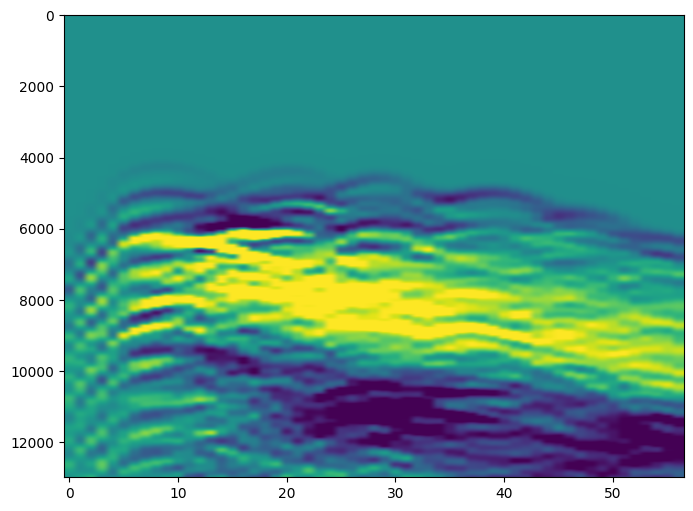

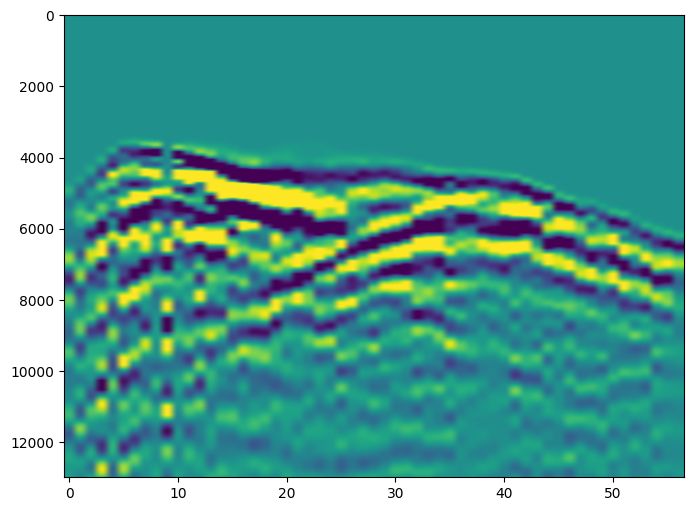

In [10]:
from matplotlib import pyplot as plt
qa = 0.005
plt.imshow(d_syn, aspect='auto', vmin=-qa, vmax=qa)
plt.show()
plt.imshow(d_obs.T, aspect='auto', vmin=-qa, vmax=qa)
plt.show()